In [1]:
import re
import string
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Harry_Potter_all_char_separated.txt to Harry_Potter_all_char_separated.txt


In [3]:
file_name = "Harry_Potter_all_char_separated.txt"

with open(file_name, "r", encoding="utf-8") as file:
    text = file.read()

print("Dataset loaded successfully")
print("Characters:", len(text))
print(text[:500])

Dataset loaded successfully
Characters: 6515219
Chapter : THE BOY WHO LIVED .| Mr and Mrs Dursley , of number four , Privet Drive , were proud to say that they were perfectly normal , thank you very much .| They were the last people you’d expect to be involved in anything strange or mysterious , because they just didn’t hold with such nonsense .| Mr Dursley was the director of a firm called Grunnings , which made drills .| He was a big , beefy man with hardly any neck , although he did have a very large mustache .| Mrs Dursley was thin and bl


In [4]:
# Convert to lowercase
text = text.lower()

# Replace | separators with spaces
text = text.replace("|", " ")

# Remove punctuation
text = text.translate(
    str.maketrans("", "", string.punctuation)
)

# Remove extra whitespace
text = re.sub(r"\s+", " ", text).strip()

print("Preprocessing completed")
print(text[:500])

Preprocessing completed
chapter the boy who lived mr and mrs dursley of number four privet drive were proud to say that they were perfectly normal thank you very much they were the last people you’d expect to be involved in anything strange or mysterious because they just didn’t hold with such nonsense mr dursley was the director of a firm called grunnings which made drills he was a big beefy man with hardly any neck although he did have a very large mustache mrs dursley was thin and blonde and had nearly twice the usu


In [5]:
# Limit vocabulary to keep training practical in Google Colab
vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

total_words = min(
    vocab_size,
    len(tokenizer.word_index) + 1
)

token_list = tokenizer.texts_to_sequences([text])[0]

print("Vocabulary size:", total_words)
print("Total tokens:", len(token_list))

Vocabulary size: 10000
Total tokens: 1170145


In [6]:
sequence_length = 20

input_sequences = []

for i in range(
    sequence_length,
    len(token_list)
):
    sequence = token_list[
        i - sequence_length : i + 1
    ]

    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1170125, 20)
y shape: (1170125,)


In [7]:
split_index = int(len(X) * 0.90)

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 1053112
Validation samples: 117013


In [9]:
embedding_dim = 128
lstm_units = 128

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=embedding_dim,
        input_shape=(sequence_length,)
    ),

    LSTM(lstm_units),

    Dense(
        total_words,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10000)          │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701,584 (10.31 MB)

 Trainable params: 2,701,584 (10.31 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/3
4114/4114 ━━━━━━━━━━━━━━━━━━━━ 906s 220ms/step - accuracy: 0.1290 - loss: 5.6712 - val_accuracy: 0.1633 - val_loss: 5.2767
Epoch 2/3
4114/4114 ━━━━━━━━━━━━━━━━━━━━ 921s 219ms/step - accuracy: 0.1793 - loss: 4.9892 - val_accuracy: 0.1797 - val_loss: 5.0790
Epoch 3/3
4114/4114 ━━━━━━━━━━━━━━━━━━━━ 905s 220ms/step - accuracy: 0.1962 - loss: 4.7519 - val_accuracy: 0.1878 - val_loss: 5.0037


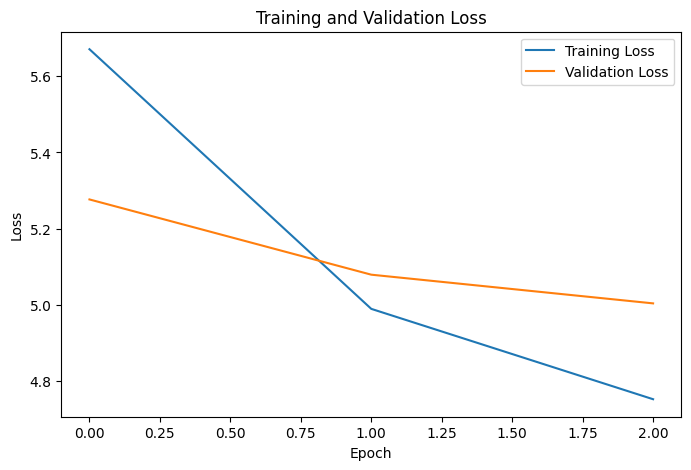

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [14]:
def generate_text(
    seed_text,
    next_words=50,
    temperature=0.8
):

    generated_text = seed_text.lower()

    for _ in range(next_words):

        # Convert text to token IDs
        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        # Keep only the last sequence_length tokens
        token_list = token_list[-sequence_length:]

        # Pad sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict next word
        predictions = model.predict(
            token_list,
            verbose=0
        )[0]

        # Apply temperature
        predictions = np.asarray(
            predictions
        ).astype("float64")

        predictions = np.log(
            predictions + 1e-8
        ) / temperature

        probabilities = np.exp(predictions)

        probabilities = (
            probabilities /
            np.sum(probabilities)
        )

        # Select next token
        predicted_id = np.random.choice(
            len(probabilities),
            p=probabilities
        )

        # Convert token ID back to word
        output_word = None

        for word, index in tokenizer.word_index.items():

            if index == predicted_id:
                output_word = word
                break

        if output_word is not None:
            generated_text += " " + output_word

    return generated_text

In [15]:
seeds = [
    "harry looked at",
    "the professor said",
    "hermione walked into",
    "ron looked around",
    "the door opened"
]

generated_outputs = {}

for seed in seeds:

    output = generate_text(
        seed_text=seed,
        next_words=50,
        temperature=0.8
    )

    generated_outputs[seed] = output

    print("=" * 80)
    print("SEED:", seed)
    print("GENERATED TEXT:")
    print(output)
    print()

SEED: harry looked at
GENERATED TEXT:
harry looked at the empty chart “ why was that ” “ now ” said harry “ harry ” said harry “ i know why i don’t know how to listen ” said ron “ well i mean ” said harry “ but he’s going to be the third term of the names

SEED: the professor said
GENERATED TEXT:
the professor said but the broomstick was now and from the crowd he was <OOV> a few moments later the door opened harry’s neck again and when he was speeding in rafters with a <OOV> until the torches upon their seats and put the wall in the shadowy floor “ good care after

SEED: hermione walked into
GENERATED TEXT:
hermione walked into a shop where the dark lord was most by the four weeks the carriage sank along the corridor ahead that had slept the note was deeply immediately the room was set the second was frightening on the morning filtering through the air where he felt the only two now on

SEED: ron looked around
GENERATED TEXT:
ron looked around by the old distant end of the old <OOV> <O

In [16]:
with open(
    "generated_samples.txt",
    "w",
    encoding="utf-8"
) as file:

    for seed, output in generated_outputs.items():

        file.write("=" * 80 + "\n")
        file.write("SEED: " + seed + "\n")
        file.write("GENERATED TEXT:\n")
        file.write(output + "\n\n")

print("generated_samples.txt created successfully")

generated_samples.txt created successfully


In [17]:
model.save("lstm_text_generation.keras")

print("Model saved successfully")

Model saved successfully


In [20]:
# Creativity Experiment: Different Temperature Values

seed = "harry looked at"

temperatures = [0.5, 0.8, 1.0]

for temp in temperatures:
    print("=" * 80)
    print("TEMPERATURE:", temp)
    print(generate_text(
        seed_text=seed,
        next_words=50,
        temperature=temp
    ))
    print()

TEMPERATURE: 0.5
harry looked at the other side of the room “ i mean that means ” “ well if you think i never don’t know ” said hermione “ yes ” said hermione “ we need to be in my office ” “ well ” said hermione “ hem ” said hermione “ so

TEMPERATURE: 0.8
harry looked at him “ no ” said hermione sternly “ it’s right ” and a voice was <OOV> by <OOV> he had no sound yet his face was nothing in the family not pretend that his father was his life broken over the air they sped more down like the corridors that

TEMPERATURE: 1.0
harry looked at his blood trip katie had snatched a pain on his wooden stare at the back of the darkness against the cauldron revolving he gathered as it was aside a handful of light soared itself was still slumping off he steered him toward the castle without the tapestry upstairs to his



In [21]:
# Creativity Experiment: Different Seed Inputs

creative_seeds = [
    "harry entered the room",
    "the professor looked at",
    "hermione said to",
    "ron walked towards",
    "the door suddenly"
]

for seed in creative_seeds:
    print("=" * 80)
    print("SEED:", seed)
    print(generate_text(
        seed_text=seed,
        next_words=40,
        temperature=0.8
    ))
    print()

SEED: harry entered the room
harry entered the room of the death eaters the tent with the doors of water with laughter from him <OOV> almost louder and <OOV> “ take them ” ron added glancing as they were not “ what’s an inquiry <OOV> ” she said she

SEED: the professor looked at
the professor looked at a magnificent locker wall in his chin however they were larger than ever “ d’you think a certain little than you can help ” he blinked came back down to his feet “ you are arrested a new snorkacks ”

SEED: hermione said to
hermione said to reassure him to finish him out of the hall with voldemort who was not still the hurried away in which their clubs had been had so far imprisoned and then he needed to fight the fragile bright contents of his

SEED: ron walked towards
ron walked towards inside the stairs and <OOV> the death eaters harry had been waiting but yet of someone as they had gone on the bottom of the fire “ no point ” said hagrid moving along the ladder and a whole newspaper

S